# Course 2, Week 1 — Hyperparameter Optimization

- [DeepLearning.AI platform](https://learn.deeplearning.ai/specializations/pytorch-for-deep-learning-professional-certificate/lesson)
- [Week notes](README.md)
- [GitHub issue #5](https://github.com/majorgilles/pytorch_for_deep_learning/issues/5)

**Focus:** Compare optimizers and schedulers, tune experiments, and improve model performance.

## Video guide

| Video | Covered notebook section |
|---|---|
| Choosing an evaluation objective | Accuracy, precision, recall, and F1 |
| Introduction to optimization | Objectives, learning rate, and data limits |
| Learning-rate schedulers | StepLR, ReduceLROnPlateau, and cosine annealing |
| Hyperparameters that affect performance | Architecture, training, and regularization |
| Designing a flexible CNN | Parameterized CIFAR-10 architecture |
| Automated search with Optuna | TPE studies for the flexible CNN |

> Open the [DeepLearning.AI course lesson list](https://learn.deeplearning.ai/specializations/pytorch-for-deep-learning-professional-certificate/lesson) to watch the course video.


## Start with a clear evaluation objective

Hyperparameter optimization needs an objective: a measurable quantity that determines whether one experiment is better than another. Choose that metric before tuning, based on the real cost of each error.

For a flower classifier, overall accuracy may be a useful starting point. For a plant-disease detector, however, the consequences differ:

- A **false positive** may trigger unnecessary treatment, so precision matters.
- A **false negative** may allow disease to spread, so recall matters.

No optimizer can compensate for optimizing the wrong objective. Record both the primary metric to optimize and secondary metrics that reveal unacceptable trade-offs.


### Classification outcomes

For one positive class such as “rose,” every prediction belongs to one of four groups:

| Actual class | Predicted rose | Outcome |
|---|---|---|
| Rose | Yes | True positive ($TP$) |
| Not rose | Yes | False positive ($FP$) |
| Not rose | No | True negative ($TN$) |
| Rose | No | False negative ($FN$) |

These counts define the common metrics:

$$
\operatorname{Accuracy}=\frac{TP+TN}{TP+TN+FP+FN},
$$

$$
\operatorname{Precision}=\frac{TP}{TP+FP},
\qquad
\operatorname{Recall}=\frac{TP}{TP+FN},
$$

$$
F_1=2\frac{\operatorname{Precision}\cdot\operatorname{Recall}}
{\operatorname{Precision}+\operatorname{Recall}}.
$$

Accuracy measures all correct predictions, precision asks whether positive predictions are trustworthy, and recall asks whether actual positives were found. The harmonic mean makes $F_1$ small when either precision or recall is small.


In [1]:
import torch
import torchmetrics
from torch import nn
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms

# Binary labels and predictions both have shape [N] = [8].
binary_targets: torch.Tensor = torch.tensor([1, 1, 1, 0, 0, 0, 0, 0])
binary_predictions: torch.Tensor = torch.tensor([1, 0, 1, 1, 0, 0, 0, 0])

tp: int = int(((binary_predictions == 1) & (binary_targets == 1)).sum())
fp: int = int(((binary_predictions == 1) & (binary_targets == 0)).sum())
tn: int = int(((binary_predictions == 0) & (binary_targets == 0)).sum())
fn: int = int(((binary_predictions == 0) & (binary_targets == 1)).sum())

accuracy: float = (tp + tn) / len(binary_targets)
precision: float = tp / (tp + fp)
recall: float = tp / (tp + fn)
f1: float = 2 * precision * recall / (precision + recall)

print(f"TP={tp}, FP={fp}, TN={tn}, FN={fn}")
print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1:        {f1:.3f}")

assert (tp, fp, tn, fn) == (2, 1, 4, 1)


TP=2, FP=1, TN=4, FN=1
Accuracy:  0.750
Precision: 0.667
Recall:    0.667
F1:        0.667


### Why accuracy can mislead

Suppose 95% of images show healthy plants. A model that always predicts “healthy” reaches 95% accuracy while detecting no diseased plants. Its recall for disease is zero.

This is why the metric must match the objective:

- Favor **precision** when false alarms are especially costly.
- Favor **recall** when missing a positive case is especially costly.
- Use **F1** when both error types matter and the classes are imbalanced.
- Keep **accuracy** when classes and error costs are reasonably balanced.

The decision threshold also affects precision and recall: requiring stronger evidence for a positive prediction usually raises precision while lowering recall.


### Average multiclass metrics

Multiclass metrics compute one-versus-rest outcomes for each class and then combine them:

- **Macro averaging** computes the metric per class and gives every class equal weight. Rare classes matter as much as common classes.
- **Micro averaging** pools decisions across all samples before computing the metric. Common classes therefore contribute more.

Macro metrics are useful for revealing poor performance on underrepresented species. Micro metrics summarize aggregate prediction performance. Report both when class frequencies are uneven rather than relying on one number.


In [2]:
def evaluate_metrics(
    model: nn.Module,
    val_dataloader: DataLoader,
    device: torch.device,
    num_classes: int = 10,
) -> dict[str, float]:
    """Evaluate a multiclass model over a validation dataset.

    Args:
        model: Model mapping images ``[N, ...]`` to logits ``[N, C]``.
        val_dataloader: Batches of input tensors and targets ``[N]``.
        device: Device used by both model and batches.
        num_classes: Number of output classes, ``C``.

    Returns:
        Macro-averaged accuracy, precision, recall, and F1 as Python floats.
    """
    model.eval()

    # Use the task-based TorchMetrics interfaces shown in the course.
    accuracy_metric = torchmetrics.Accuracy(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    precision_metric = torchmetrics.Precision(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    recall_metric = torchmetrics.Recall(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)
    f1_metric = torchmetrics.F1Score(
        task="multiclass", num_classes=num_classes, average="macro"
    ).to(device)

    with torch.no_grad():
        for images, targets in val_dataloader:
            images = images.to(device)
            targets = targets.to(device)
            logits: torch.Tensor = model(images)  # Shape [N, C].

            # TorchMetrics accepts logits and selects the largest class score.
            accuracy_metric.update(logits, targets)
            precision_metric.update(logits, targets)
            recall_metric.update(logits, targets)
            f1_metric.update(logits, targets)

    return {
        "accuracy_macro": accuracy_metric.compute().item(),
        "precision_macro": precision_metric.compute().item(),
        "recall_macro": recall_metric.compute().item(),
        "f1_macro": f1_metric.compute().item(),
    }


# Build deterministic logits [N, C] for a runnable DataLoader example.
multiclass_targets: torch.Tensor = torch.tensor([0, 0, 0, 0, 0, 1, 1, 1, 2, 2])
multiclass_predictions: torch.Tensor = torch.tensor([0, 0, 0, 0, 0, 0, 0, 1, 0, 2])
multiclass_logits: torch.Tensor = torch.full((10, 3), fill_value=-1.0)
multiclass_logits[torch.arange(10), multiclass_predictions] = 1.0

validation_dataset: TensorDataset = TensorDataset(multiclass_logits, multiclass_targets)
validation_loader: DataLoader = DataLoader(validation_dataset, batch_size=4)
identity_model: nn.Identity = nn.Identity()
evaluation_device: torch.device = torch.device("cpu")

metric_results: dict[str, float] = evaluate_metrics(
    model=identity_model,
    val_dataloader=validation_loader,
    device=evaluation_device,
    num_classes=3,
)

for metric_name, metric_value in metric_results.items():
    print(f"{metric_name:16}: {metric_value:.3f}")

assert all(isinstance(value, float) for value in metric_results.values())
assert metric_results["precision_macro"] > metric_results["recall_macro"]


accuracy_macro  : 0.611
precision_macro : 0.875
recall_macro    : 0.611
f1_macro        : 0.645


### Learning checkpoint

Before tuning a model, answer:

1. What real outcome should improve?
2. Which error is more costly: a false positive or a false negative?
3. Are classes imbalanced?
4. Should every class count equally (`macro`) or every sample count equally (`micro`)?

Then select one primary optimization metric and monitor the others as guardrails. The next step is to tune training choices against that explicit objective.


## Optimization: improve a measurable objective

Optimization searches for values that maximize or minimize an objective. In machine learning, that objective might be:

- **maximized:** validation accuracy, precision, recall, or F1;
- **minimized:** validation loss, mean squared error, inference latency, training time, or memory use.

For the botanical classifier, an initial accuracy of 48% is a baseline, not enough information to prescribe a fix. First choose the metric that reflects the application's goal, then change one or more training settings and measure whether validation performance improves.

Training loss guides gradient-based parameter updates. Hyperparameter selection should use validation results; repeatedly selecting configurations from test performance would leak information from the final evaluation set.


### Parameters versus hyperparameters

**Parameters** are learned by the optimizer during training, such as convolution kernels, linear weights, and biases.

**Hyperparameters** control the training process or model design and are selected outside ordinary gradient descent. Examples include:

- learning rate,
- batch size,
- optimizer choice and weight decay,
- number and width of layers,
- dropout probability,
- data-augmentation settings.

Hyperparameter optimization compares training runs to find a configuration that performs well on the chosen validation objective.


### Learning rate: the optimizer's step size

The learning rate controls how far an optimizer moves in response to a gradient:

$$
\theta_{t+1}=\theta_t-\eta\nabla_\theta L(\theta_t),
$$

where $\eta$ is the learning rate.

- **Too small:** updates are stable but slow; a fixed training budget may end before reaching a good solution.
- **Too large:** updates can overshoot good values, oscillate, or diverge.
- **Suitable range:** training makes meaningful progress without becoming unstable.

Consequently, validation performance often peaks between poor low- and high-learning-rate regions. Search learning rates on a logarithmic scale because useful values commonly differ by orders of magnitude.


In [3]:
import matplotlib.pyplot as plt


def optimize_quadratic(
    learning_rate: float,
    steps: int = 20,
) -> tuple[float, float]:
    """Minimize ``(parameter - 3)^2`` with SGD.

    Args:
        learning_rate: SGD step size.
        steps: Number of parameter updates.

    Returns:
        Final scalar parameter and objective values.
    """
    parameter: torch.Tensor = torch.tensor(0.0, requires_grad=True)
    optimizer: torch.optim.SGD = torch.optim.SGD([parameter], lr=learning_rate)

    for _ in range(steps):
        optimizer.zero_grad()
        objective: torch.Tensor = (parameter - 3.0).square()  # Scalar shape [].
        objective.backward()
        optimizer.step()

    final_objective: torch.Tensor = (parameter.detach() - 3.0).square()
    return parameter.item(), final_objective.item()


learning_rates: list[float] = [0.001, 0.01, 0.1, 0.5, 1.1]
optimization_results: list[tuple[float, float]] = [
    optimize_quadratic(learning_rate) for learning_rate in learning_rates
]

for learning_rate, (final_parameter, final_objective) in zip(
    learning_rates, optimization_results, strict=True
):
    print(
        f"lr={learning_rate:>5}: parameter={final_parameter:>9.3f}, "
        f"objective={final_objective:>12.6f}"
    )

assert optimization_results[3][1] < optimization_results[0][1]
assert optimization_results[3][1] < optimization_results[-1][1]


lr=0.001: parameter=    0.118, objective=    8.307382
lr= 0.01: parameter=    0.997, objective=    4.011303
lr=  0.1: parameter=    2.965, objective=    0.001196
lr=  0.5: parameter=    3.000, objective=    0.000000
lr=  1.1: parameter= -112.013, objective=13227.977539


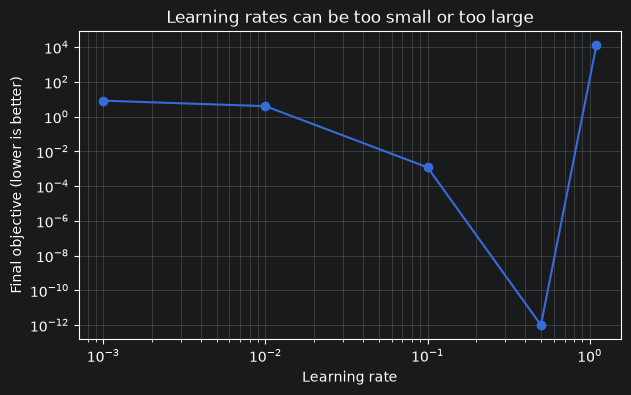

In [4]:
final_objectives: list[float] = [
    max(final_objective, 1e-12)
    for _, final_objective in optimization_results
]

figure, axis = plt.subplots(figsize=(7, 4))
axis.plot(learning_rates, final_objectives, marker="o")
axis.set_xscale("log")
axis.set_yscale("log")
axis.set_xlabel("Learning rate")
axis.set_ylabel("Final objective (lower is better)")
axis.set_title("Learning rates can be too small or too large")
axis.grid(True, which="both", alpha=0.3)
plt.show()


### Check external limits before tuning the model

Hyperparameter search cannot rescue a broken learning problem. Before spending compute, inspect:

1. **Data quantity:** Are there enough examples, especially for rare classes?
2. **Label quality:** Are species names correct and consistent?
3. **Input quality:** Are images sharp enough and relevant objects visible?
4. **Class balance:** Does the training distribution represent the cases that matter?
5. **Preprocessing:** Are resizing, cropping, normalization, and augmentation appropriate?
6. **Split integrity:** Are duplicate or related images leaking across train and validation sets?

Collecting representative data or correcting labels can provide more improvement than an extensive hyperparameter sweep.


### A disciplined optimization workflow

1. Define one primary validation objective and any constraints.
2. Establish a reproducible baseline.
3. Audit data and preprocessing.
4. Choose a bounded search space for a few influential hyperparameters.
5. Train each configuration under comparable conditions.
6. Select using validation results and record all trials.
7. Evaluate the selected configuration on the test set once.

Optimization can target multiple concerns. For example, maximize macro F1 subject to an inference-latency limit rather than treating speed and quality as unrelated numbers.


### Learning checkpoint

You should now be able to distinguish learned parameters from selected hyperparameters, explain why learning rates can be too small or too large, and identify data problems that should be addressed before model tuning.

The objective supplies direction; the search strategy determines which hyperparameter configurations to try efficiently.


## Adjust the learning rate during training

A fixed high learning rate can improve performance quickly but later oscillate around a good solution. A low learning rate can make precise updates but may require many epochs. A **learning-rate scheduler** changes the optimizer's learning rate over time, allowing training to make larger early updates and smaller later refinements.

Schedulers do not guarantee higher accuracy. Their type and settings—such as decay factor, patience, cycle length, and minimum learning rate—are additional hyperparameters. Start with a constant-learning-rate baseline, then add a scheduler when the learning curves justify the extra complexity.


### `StepLR`: reduce at fixed intervals

`StepLR` multiplies the learning rate by $\gamma$ every `step_size` epochs:

$$
\eta_t = \eta_0\,\gamma^{\left\lfloor t/s \right\rfloor},
$$

where $s$ is the step size. With $\eta_0=1$, $s=3$, and $\gamma=0.2$, the rate becomes $0.2$ after epoch 3 and $0.04$ after epoch 6. This schedule is predictable but does not react to model performance.


In [5]:
step_parameter: torch.Tensor = torch.tensor(0.0, requires_grad=True)
step_optimizer: torch.optim.SGD = torch.optim.SGD([step_parameter], lr=1.0)
step_scheduler: torch.optim.lr_scheduler.StepLR = torch.optim.lr_scheduler.StepLR(
    step_optimizer,
    step_size=3,
    gamma=0.2,
)
step_rates: list[float] = [step_optimizer.param_groups[0]["lr"]]

for _ in range(9):
    step_optimizer.step()  # A real loop performs loss.backward() before this call.
    step_scheduler.step()  # Update after the epoch's optimizer steps.
    step_rates.append(step_optimizer.param_groups[0]["lr"])

for epoch, learning_rate in enumerate(step_rates):
    print(f"Epoch {epoch:>2}: lr={learning_rate:.5f}")

assert abs(step_rates[3] - 0.2) < 1e-9
assert abs(step_rates[6] - 0.04) < 1e-9


Epoch  0: lr=1.00000
Epoch  1: lr=1.00000
Epoch  2: lr=1.00000
Epoch  3: lr=0.20000
Epoch  4: lr=0.20000
Epoch  5: lr=0.20000
Epoch  6: lr=0.04000
Epoch  7: lr=0.04000
Epoch  8: lr=0.04000
Epoch  9: lr=0.00800


### `ReduceLROnPlateau`: react when progress stalls

`ReduceLROnPlateau` monitors a validation metric and reduces the learning rate when improvement stops:

- Use `mode="max"` for metrics that should increase, such as accuracy or F1.
- Use `mode="min"` for metrics that should decrease, such as validation loss.
- `patience` controls how many unimproved epochs are tolerated.
- `factor` multiplies the learning rate when a reduction occurs.

Unlike epoch-based schedulers, call `scheduler.step(metric)` **after validation** so the scheduler can inspect the current metric. If validation loss is monitored, improvement means decreasing—not increasing.


In [6]:
plateau_parameter: torch.Tensor = torch.tensor(0.0, requires_grad=True)
plateau_optimizer: torch.optim.SGD = torch.optim.SGD([plateau_parameter], lr=0.1)
plateau_scheduler: torch.optim.lr_scheduler.ReduceLROnPlateau = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(
        plateau_optimizer,
        mode="max",  # Validation accuracy should increase.
        factor=0.2,
        patience=2,
    )
)
validation_accuracies: list[float] = [0.50, 0.60, 0.62, 0.62, 0.61, 0.60, 0.66]
plateau_rates: list[float] = []

for epoch, validation_accuracy in enumerate(validation_accuracies, start=1):
    plateau_optimizer.step()
    plateau_scheduler.step(validation_accuracy)
    learning_rate: float = plateau_optimizer.param_groups[0]["lr"]
    plateau_rates.append(learning_rate)
    print(f"Epoch {epoch}: accuracy={validation_accuracy:.2f}, lr={learning_rate:.5f}")

assert min(plateau_rates) < plateau_rates[0]


Epoch 1: accuracy=0.50, lr=0.10000
Epoch 2: accuracy=0.60, lr=0.10000
Epoch 3: accuracy=0.62, lr=0.10000
Epoch 4: accuracy=0.62, lr=0.10000
Epoch 5: accuracy=0.61, lr=0.10000
Epoch 6: accuracy=0.60, lr=0.02000
Epoch 7: accuracy=0.66, lr=0.02000


### `CosineAnnealingLR`: decay smoothly

`CosineAnnealingLR` lowers the learning rate along a cosine curve over `T_max` steps toward `eta_min`:

$$
\eta_t = \eta_{\min}
+ \frac{1}{2}(\eta_{\max}-\eta_{\min})
\left(1+\cos\left(\frac{\pi t}{T_{\max}}\right)\right).
$$

The transition is gradual rather than abrupt. `T_max` must match the unit in which `scheduler.step()` is called; in this example it is the number of epochs.


In [7]:
cosine_parameter: torch.Tensor = torch.tensor(0.0, requires_grad=True)
cosine_optimizer: torch.optim.SGD = torch.optim.SGD([cosine_parameter], lr=0.1)
cosine_scheduler: torch.optim.lr_scheduler.CosineAnnealingLR = (
    torch.optim.lr_scheduler.CosineAnnealingLR(
        cosine_optimizer,
        T_max=10,
        eta_min=0.001,
    )
)
cosine_rates: list[float] = [cosine_optimizer.param_groups[0]["lr"]]

for _ in range(10):
    cosine_optimizer.step()
    cosine_scheduler.step()
    cosine_rates.append(cosine_optimizer.param_groups[0]["lr"])

for epoch, learning_rate in enumerate(cosine_rates):
    print(f"Epoch {epoch:>2}: lr={learning_rate:.5f}")

assert abs(cosine_rates[-1] - 0.001) < 1e-9


Epoch  0: lr=0.10000
Epoch  1: lr=0.09758
Epoch  2: lr=0.09055
Epoch  3: lr=0.07960
Epoch  4: lr=0.06580
Epoch  5: lr=0.05050
Epoch  6: lr=0.03520
Epoch  7: lr=0.02140
Epoch  8: lr=0.01045
Epoch  9: lr=0.00342
Epoch 10: lr=0.00100


### Place scheduler updates correctly

For `StepLR` and `CosineAnnealingLR`, update once after the epoch's training:

```python
for epoch in range(num_epochs):
    train_one_epoch(...)
    validate(...)
    scheduler.step()
```

For `ReduceLROnPlateau`, pass the monitored validation result:

```python
for epoch in range(num_epochs):
    train_one_epoch(...)
    validation_loss, validation_accuracy = validate(...)
    scheduler.step(validation_accuracy)  # mode="max"
```

Record the learning rate alongside loss and validation metrics. Otherwise, a sudden change in a learning curve may be impossible to connect to a scheduler update.


### Learning checkpoint

- `StepLR` follows a fixed periodic decay.
- `ReduceLROnPlateau` responds to a monitored validation metric.
- `CosineAnnealingLR` follows a smooth predetermined curve.

Choose a scheduler based on observed training behavior, compare it against a constant-rate baseline, and tune its settings using validation data rather than the test set.


## Hyperparameters that affect model performance

Hyperparameters fall into three useful—but sometimes overlapping—categories:

| Category | Examples | Main trade-off |
|---|---|---|
| **Architecture** | depth, layer width, convolution filters, kernel size, padding, activation | capacity versus compute and overfitting |
| **Training** | learning rate, scheduler, optimizer, batch size, epoch budget | speed, stability, memory, and final quality |
| **Regularization** | weight decay, dropout, early stopping, augmentation, batch normalization | training fit versus generalization |

These are selected outside ordinary gradient descent. The optimizer learns model parameters such as weights and biases; an experiment process chooses hyperparameters by comparing validation results.


### Architectural hyperparameters

More layers and neurons increase representational capacity, but also increase parameter count, computation, and the opportunity to overfit. CNNs add choices such as channel counts, kernel sizes, strides, and padding. Start with the smallest architecture that beats a meaningful baseline, then add capacity only when the learning curves suggest underfitting.

ReLU is a common hidden-layer default. Output activation depends on the loss interface:

- For multiclass classification with `CrossEntropyLoss`, return raw logits—do **not** put softmax in the model.
- For binary or multilabel classification with `BCEWithLogitsLoss`, return raw logits—do **not** put sigmoid in the model.
- Apply sigmoid or softmax afterward when probabilities are needed for interpretation.


In [8]:
# A small baseline for RGB images [N, 3, 32, 32] and 15 classes.
baseline_model: nn.Sequential = nn.Sequential(
    nn.Flatten(),
    nn.Linear(in_features=3 * 32 * 32, out_features=64),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(in_features=64, out_features=15),  # Raw logits [N, 15].
)

baseline_parameters: int = sum(
    parameter.numel() for parameter in baseline_model.parameters()
)
baseline_batch: torch.Tensor = torch.rand(8, 3, 32, 32)
baseline_logits: torch.Tensor = baseline_model(baseline_batch)

print(f"Trainable parameters: {baseline_parameters:,}")
print(f"Input [N, C, H, W]: {baseline_batch.shape}")
print(f"Logits [N, K]: {baseline_logits.shape}")
assert baseline_logits.shape == (8, 15)


Trainable parameters: 197,647
Input [N, C, H, W]: torch.Size([8, 3, 32, 32])
Logits [N, K]: torch.Size([8, 15])


### Training hyperparameters

The optimizer determines how gradients become parameter updates:

- **SGD** applies gradient-based updates directly and can add momentum.
- **RMSprop** adapts each parameter's step using a moving average of squared gradients.
- **Adam** combines adaptive per-parameter rates with first- and second-moment estimates. This convenience costs more optimizer-state memory than plain SGD.

Batch size is the number of samples used for one parameter update. Small batches use less accelerator memory and produce noisier gradient estimates. Large batches often improve hardware throughput and produce smoother estimates, but require more memory and perform fewer updates per epoch. Neither size universally converges better; measure on the actual hardware and task. Values such as 32 or 64 are starting points, not rules.


In [9]:
import math

samples_per_epoch: int = 10_000
candidate_batch_sizes: list[int] = [16, 32, 64, 128]

for candidate_batch_size in candidate_batch_sizes:
    updates_per_epoch: int = math.ceil(samples_per_epoch / candidate_batch_size)
    print(
        f"batch_size={candidate_batch_size:>3}: "
        f"updates_per_epoch={updates_per_epoch:>3}"
    )

# AdamW applies decoupled weight decay and is a practical baseline optimizer.
baseline_optimizer: torch.optim.AdamW = torch.optim.AdamW(
    baseline_model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)


batch_size= 16: updates_per_epoch=625
batch_size= 32: updates_per_epoch=313
batch_size= 64: updates_per_epoch=157
batch_size=128: updates_per_epoch= 79


### Regularization hyperparameters

- **Weight decay** discourages large parameters. With SGD, L2 regularization and weight decay are closely related; `AdamW` applies weight decay separately from Adam's gradient update.
- **Dropout** randomly masks activations during training, reducing reliance on particular neurons. Typical starting probabilities range from 0.1 to 0.5; `model.eval()` disables it.
- **Early stopping** ends training after a validation metric fails to improve for a chosen patience period.
- **Batch normalization** normalizes batch activation statistics during training and maintains running statistics for evaluation. Its primary purpose is stable, efficient optimization; any regularizing effect is secondary and batch-size dependent.

For an L2-style penalty, the objective includes a term proportional to squared weight magnitude:

$$
L_{\text{regularized}} = L_{\text{data}} + \lambda \sum_i w_i^2.
$$

Regularization addresses a gap between training and validation performance. It is not a substitute for adequate, representative, correctly labeled data.


In [10]:
validation_accuracies: list[float] = [0.48, 0.55, 0.59, 0.588, 0.587, 0.586]
patience: int = 3
minimum_improvement: float = 0.002
best_accuracy: float = float("-inf")
epochs_without_improvement: int = 0
stopped_epoch: int | None = None

for epoch, validation_accuracy in enumerate(validation_accuracies, start=1):
    if validation_accuracy > best_accuracy + minimum_improvement:
        best_accuracy = validation_accuracy
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        stopped_epoch = epoch
        print(f"Early stopping at epoch {epoch}; best accuracy={best_accuracy:.3f}")
        break

assert stopped_epoch == 6


Early stopping at epoch 6; best accuracy=0.590


### Establish a baseline, then tune iteratively

A useful baseline is small, reproducible, and fast enough to run repeatedly. It verifies that the pipeline works and establishes a performance floor that added complexity must beat.

1. Start with framework defaults and record the data split, random seed, metrics, runtime, and parameter count.
2. Compare against a relevant published or established configuration when one exists.
3. Prioritize influential choices such as learning rate, batch size, and model capacity.
4. Change a bounded set of values and compare them under the same conditions.
5. Add regularization when training performance exceeds validation performance.
6. Keep changes only when they improve the chosen objective or an explicit constraint.

Hyperparameter tuning is structured experimentation, not guessing every possible combination at once.


### Learning checkpoint

You should now be able to classify a hyperparameter as architectural, training-related, or regularizing; explain its main trade-offs; and choose a small set of high-impact candidates to test after establishing a baseline.

Treat categories as an organizing tool rather than rigid boundaries. For example, batch normalization changes architecture, optimization behavior, and sometimes regularization at the same time.


## Design a flexible CNN for experimentation

CIFAR-10 contains $32 \times 32$ RGB images from 10 classes. A configurable model makes it possible to compare architectural choices without rewriting the class for every experiment.

This example exposes five hyperparameters:

1. `n_layers`: number of convolutional blocks,
2. `n_filters`: output channels for each block,
3. `kernel_sizes`: kernel size for each block,
4. `fc_size`: width of the hidden fully connected layer,
5. `dropout_rate`: classifier dropout probability.

Every convolutional block follows `Conv2d → ReLU → MaxPool2d`. Convolution uses stride 1 and same-size padding for odd kernels; pooling then halves height and width. For three blocks:

$$
[ N,3,32,32 ] \rightarrow [ N,32,16,16 ] \rightarrow
[ N,64,8,8 ] \rightarrow [ N,128,4,4 ].
$$


In [11]:
class FlexibleCNN(nn.Module):
    """Build a configurable classifier for 32 x 32 RGB images.

    Args:
        n_layers: Number of convolutional blocks.
        n_filters: Output-channel count for each block.
        kernel_sizes: Odd kernel size for each block.
        fc_size: Number of neurons in the hidden linear layer.
        dropout_rate: Probability of masking a classifier activation.
        num_classes: Number of output classes.

    Shape:
        Input: ``[N, 3, H, W]``.
        Output: ``[N, num_classes]`` logits.
    """

    def __init__(
        self,
        n_layers: int,
        n_filters: list[int],
        kernel_sizes: list[int],
        fc_size: int,
        dropout_rate: float,
        num_classes: int = 10,
    ) -> None:
        super().__init__()
        if n_layers < 1:
            raise ValueError("n_layers must be at least 1")
        if len(n_filters) != n_layers or len(kernel_sizes) != n_layers:
            raise ValueError("n_filters and kernel_sizes must match n_layers")
        if any(kernel_size < 1 or kernel_size % 2 == 0 for kernel_size in kernel_sizes):
            raise ValueError("kernel_sizes must contain positive odd integers")
        if not 0.0 <= dropout_rate < 1.0:
            raise ValueError("dropout_rate must be in [0, 1)")

        blocks: list[nn.Module] = []
        in_channels: int = 3  # CIFAR-10 images are RGB.

        for layer_index in range(n_layers):
            out_channels: int = n_filters[layer_index]
            kernel_size: int = kernel_sizes[layer_index]
            padding: int = (kernel_size - 1) // 2  # Same spatial size for odd kernels.

            blocks.append(
                nn.Sequential(
                    nn.Conv2d(
                        in_channels=in_channels,
                        out_channels=out_channels,
                        kernel_size=kernel_size,
                        padding=padding,
                    ),
                    nn.ReLU(),
                    nn.MaxPool2d(kernel_size=2),
                )
            )
            in_channels = out_channels  # Connect this block to the next one.

        self.features: nn.Sequential = nn.Sequential(*blocks)
        self.classifier: nn.Sequential = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout_rate),
            nn.LazyLinear(out_features=fc_size),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features=fc_size, out_features=num_classes),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        """Map image batches ``[N, 3, H, W]`` to logits ``[N, K]``."""
        features: torch.Tensor = self.features(images)
        return self.classifier(features)


### Infer the flattened size safely

The flattened feature count depends on input size, final channel count, and the number of pooling blocks. Hard-coding it makes configurations fragile.

`nn.LazyLinear` is PyTorch's built-in solution: its `in_features` and weight shape are materialized from the first input. Run one representative batch before inspecting parameter counts or creating the optimizer. This keeps all trainable layers registered in `__init__()` and avoids creating new parameters inside `forward()`.

Pooling still imposes a real limit. For a $32 \times 32$ input, at most five ordinary halving operations fit before a spatial dimension would become zero.


In [12]:
# Configuration A: three blocks produce [N, 128, 4, 4].
flexible_model: FlexibleCNN = FlexibleCNN(
    n_layers=3,
    n_filters=[32, 64, 128],
    kernel_sizes=[3, 3, 3],
    fc_size=256,
    dropout_rate=0.3,
)
cifar_batch: torch.Tensor = torch.rand(8, 3, 32, 32)
flexible_logits: torch.Tensor = flexible_model(cifar_batch)
first_linear = flexible_model.classifier[2]
assert isinstance(first_linear, nn.Linear)

print(f"Configuration A logits [N, K]: {flexible_logits.shape}")
print(f"Configuration A flattened features: {first_linear.in_features}")
assert flexible_logits.shape == (8, 10)
assert first_linear.in_features == 128 * 4 * 4

# Configuration B changes depth, filters, kernels, hidden width, and dropout.
wide_kernel_model: FlexibleCNN = FlexibleCNN(
    n_layers=2,
    n_filters=[64, 32],
    kernel_sizes=[3, 5],
    fc_size=128,
    dropout_rate=0.5,
)
wide_kernel_logits: torch.Tensor = wide_kernel_model(cifar_batch)
wide_first_linear = wide_kernel_model.classifier[2]
assert isinstance(wide_first_linear, nn.Linear)

print(f"Configuration B logits [N, K]: {wide_kernel_logits.shape}")
print(f"Configuration B flattened features: {wide_first_linear.in_features}")
assert wide_first_linear.in_features == 32 * 8 * 8


Configuration A logits [N, K]: torch.Size([8, 10])
Configuration A flattened features: 2048
Configuration B logits [N, K]: torch.Size([8, 10])
Configuration B flattened features: 2048


In [13]:
# Materialize LazyLinear before constructing the optimizer.
flexible_optimizer: torch.optim.Adam = torch.optim.Adam(
    flexible_model.parameters(),
    lr=1e-3,
)
cifar_targets: torch.Tensor = torch.randint(0, 10, size=(8,))  # Shape [N].
classification_loss: nn.CrossEntropyLoss = nn.CrossEntropyLoss()
weights_before: torch.Tensor = flexible_model.features[0][0].weight.detach().clone()

flexible_model.train()
flexible_optimizer.zero_grad()
training_logits: torch.Tensor = flexible_model(cifar_batch)  # Shape [N, 10].
training_loss: torch.Tensor = classification_loss(training_logits, cifar_targets)
training_loss.backward()
flexible_optimizer.step()

print(f"Training loss: {training_loss.item():.4f}")
assert not torch.equal(weights_before, flexible_model.features[0][0].weight.detach())


Training loss: 2.2846


### Learning checkpoint

A flexible architecture turns candidate configurations into constructor arguments while preserving one tested data flow. Validate dependent list lengths and kernel constraints, connect each block's output channels to the next block's input channels, and materialize lazy layers with a representative batch before optimization.

Flexibility should serve a real experiment. Expose the few hyperparameters you intend to tune rather than turning every constant into configuration.


## Search hyperparameters with Optuna

The flexible CNN defines a search interface; Optuna chooses configurations to evaluate through that interface. Each **trial** samples hyperparameters, trains a fresh model on real CIFAR-10 images, measures validation accuracy, and records the result. A **study** coordinates trials and tracks the best observed configuration.

This section uses a balanced subset of CIFAR-10 to keep the notebook practical while preserving a real image-classification signal. It optimizes five architectural hyperparameters while keeping learning rate, batch size, and epoch budget fixed.


### Grid, random, and TPE search

| Strategy | Behavior | Trade-off |
|---|---|---|
| Grid search | Evaluates every specified combination | Complete for a small discrete grid, but grows exponentially |
| Random search | Samples independent configurations | Covers large spaces cheaply, but does not learn from prior trials |
| TPE | Uses completed trials to bias later samples toward promising regions | Adaptive and often efficient, but not guaranteed to find the global optimum |

Two hyperparameters with five values each create $5^2=25$ grid combinations. Optuna's default Tree-structured Parzen Estimator (TPE) can also represent conditional spaces: filter and kernel choices exist only for convolutional blocks that a trial actually creates.


In [14]:
import optuna

# Download the real CIFAR-10 training split through torchvision's dataset API.
cifar10_transform: transforms.Compose = transforms.Compose(
    [
        transforms.ToTensor(),  # PIL [H, W, C] -> float tensor [C, H, W].
        transforms.Normalize(
            mean=(0.4914, 0.4822, 0.4465),
            std=(0.2470, 0.2435, 0.2616),
        ),
    ]
)
cifar10_full: datasets.CIFAR10 = datasets.CIFAR10(
    root="data/cifar10",
    train=True,
    download=True,
    transform=cifar10_transform,
)

# Select the same number from every class for a balanced, reproducible study.
targets_tensor: torch.Tensor = torch.tensor(cifar10_full.targets)
index_generator: torch.Generator = torch.Generator().manual_seed(42)
train_indices: list[int] = []
validation_indices: list[int] = []
train_per_class: int = 100
validation_per_class: int = 20

for class_index in range(10):
    class_indices: torch.Tensor = torch.where(targets_tensor == class_index)[0]
    shuffled_indices: torch.Tensor = class_indices[
        torch.randperm(len(class_indices), generator=index_generator)
    ]
    train_indices.extend(shuffled_indices[:train_per_class].tolist())
    validation_indices.extend(
        shuffled_indices[
            train_per_class : train_per_class + validation_per_class
        ].tolist()
    )

optuna_train_dataset: Subset = Subset(cifar10_full, train_indices)
optuna_validation_dataset: Subset = Subset(cifar10_full, validation_indices)

sample_image, sample_target = optuna_train_dataset[0]
print(f"Training samples: {len(optuna_train_dataset)}")
print(f"Validation samples: {len(optuna_validation_dataset)}")
print(f"Sample image [C, H, W]: {sample_image.shape}; label: {sample_target}")

assert sample_image.shape == (3, 32, 32)
assert len(optuna_train_dataset) == 1_000
assert len(optuna_validation_dataset) == 200


100%|██████████| 170M/170M [00:26<00:00, 6.39MB/s] 


Training samples: 1000
Validation samples: 200
Sample image [C, H, W]: torch.Size([3, 32, 32]); label: 0


In [15]:
def objective(trial: optuna.Trial, device: torch.device) -> float:
    """Train one sampled FlexibleCNN and return validation accuracy."""
    n_layers: int = trial.suggest_int("n_layers", 1, 3)
    n_filters: list[int] = [
        trial.suggest_categorical(f"n_filters_{index}", [16, 32, 64, 128])
        for index in range(n_layers)
    ]
    kernel_sizes: list[int] = [
        trial.suggest_categorical(f"kernel_size_{index}", [3, 5])
        for index in range(n_layers)
    ]
    dropout_rate: float = trial.suggest_float("dropout_rate", 0.1, 0.5)
    fc_size: int = trial.suggest_int("fc_size", 64, 256, step=64)

    torch.manual_seed(1_000 + trial.number)
    model: FlexibleCNN = FlexibleCNN(
        n_layers=n_layers,
        n_filters=n_filters,
        kernel_sizes=kernel_sizes,
        fc_size=fc_size,
        dropout_rate=dropout_rate,
        num_classes=10,
    ).to(device)

    train_loader: DataLoader = DataLoader(
        optuna_train_dataset, batch_size=32, shuffle=True
    )
    validation_loader: DataLoader = DataLoader(
        optuna_validation_dataset, batch_size=32, shuffle=False
    )

    # Materialize LazyLinear before creating the optimizer.
    example_images, _ = next(iter(train_loader))
    with torch.no_grad():
        model(example_images.to(device))

    optimizer: torch.optim.Adam = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_function: nn.CrossEntropyLoss = nn.CrossEntropyLoss()

    for epoch in range(2):
        model.train()
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            loss: torch.Tensor = loss_function(model(images), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        correct: int = 0
        total: int = 0
        with torch.no_grad():
            for images, labels in validation_loader:
                images = images.to(device)
                labels = labels.to(device)
                predictions: torch.Tensor = model(images).argmax(dim=1)
                correct += int((predictions == labels).sum())
                total += labels.numel()

        validation_accuracy: float = correct / total
        trial.report(validation_accuracy, step=epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return validation_accuracy


In [16]:
optimization_device: torch.device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
sampler: optuna.samplers.TPESampler = optuna.samplers.TPESampler(seed=42)
study: optuna.Study = optuna.create_study(direction="maximize", sampler=sampler)

# Eight short trials show real CIFAR-10 variation; increase this for a serious study.
study.optimize(
    lambda trial: objective(trial, optimization_device),
    n_trials=8,
)

print(f"Best validation accuracy: {study.best_value:.3f}")
print("Best sampled parameters:")
for parameter_name, parameter_value in study.best_trial.params.items():
    print(f"  {parameter_name}: {parameter_value}")

assert len(study.trials) == 8


[I 2026-09-12 20:24:10,075] A new study created in memory with name: no-name-6caca968-ae41-47b6-a311-a594b4aff2fc
[I 2026-09-12 20:24:10,902] Trial 0 finished with value: 0.34 and parameters: {'n_layers': 2, 'n_filters_0': 16, 'n_filters_1': 64, 'kernel_size_0': 3, 'kernel_size_1': 3, 'dropout_rate': 0.18493564427131048, 'fc_size': 64}. Best is trial 0 with value: 0.34.
[I 2026-09-12 20:24:11,253] Trial 1 finished with value: 0.34 and parameters: {'n_layers': 1, 'n_filters_0': 32, 'kernel_size_0': 3, 'dropout_rate': 0.21685785941408728, 'fc_size': 128}. Best is trial 0 with value: 0.34.
[I 2026-09-12 20:24:11,652] Trial 2 finished with value: 0.405 and parameters: {'n_layers': 2, 'n_filters_0': 16, 'n_filters_1': 32, 'kernel_size_0': 5, 'kernel_size_1': 3, 'dropout_rate': 0.13906884560255356, 'fc_size': 192}. Best is trial 2 with value: 0.405.
[I 2026-09-12 20:24:12,138] Trial 3 finished with value: 0.36 and parameters: {'n_layers': 2, 'n_filters_0': 128, 'n_filters_1': 32, 'kernel_siz

Best validation accuracy: 0.405
Best sampled parameters:
  n_layers: 2
  n_filters_0: 16
  n_filters_1: 32
  kernel_size_0: 5
  kernel_size_1: 3
  dropout_rate: 0.13906884560255356
  fc_size: 192


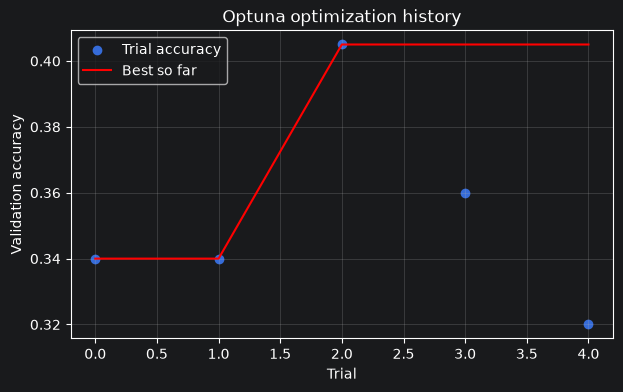

In [17]:
completed_trials: list[optuna.trial.FrozenTrial] = [
    trial
    for trial in study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]
trial_numbers: list[int] = [trial.number for trial in completed_trials]
trial_values: list[float] = [float(trial.value) for trial in completed_trials]
best_so_far: list[float] = []

for trial_value in trial_values:
    best_so_far.append(max(best_so_far[-1], trial_value) if best_so_far else trial_value)

figure, axis = plt.subplots(figsize=(7, 4))
axis.scatter(trial_numbers, trial_values, label="Trial accuracy")
axis.plot(trial_numbers, best_so_far, color="red", label="Best so far")
axis.set_xlabel("Trial")
axis.set_ylabel("Validation accuracy")
axis.set_title("Optuna optimization history")
axis.legend()
axis.grid(alpha=0.3)
plt.show()

assert best_so_far[-1] == study.best_value


### Interpret the study

Optuna can visualize optimization history, parameter importance, and parallel coordinates. Importance estimates describe associations within the completed study; they do not prove that a parameter causes performance changes. Estimates based on few trials are especially unstable.

Parallel-coordinate plots help reveal interactions by drawing each trial across parameter axes. Look for strong trials clustering around values or combinations, but confirm apparent patterns with additional trials.

Fixing an influential parameter can reduce a later search space, but lock it only when evidence is stable. Hyperparameters interact: the best filter count at two layers may not remain best at three layers.


### From the best trial to a final model

`study.best_trial` is the best **observed** trial, not a guarantee of the globally optimal configuration. Deep-learning results vary with initialization, data order, and augmentation, so promising configurations should be repeated across seeds.

After selecting a configuration:

1. reconstruct the model from `study.best_trial.params`,
2. confirm it with longer training or repeated runs,
3. retrain using all permitted development data,
4. evaluate once on the untouched CIFAR-10 test split,
5. retain the study configuration and random seeds for reproducibility.

The balanced subset above makes trials faster but produces noisier estimates than the full training set. Use more data, more epochs, and more trials for a meaningful final search; never tune against the CIFAR-10 test split.
